# Spectral Example: 01_dirac_forward_inverse

This notebook runs MP forward and MP inverse experiments for one YAML config,
then displays saved comparison figures and metadata.


In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = next(
    (
        p
        for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
        if (p / 'pyproject.toml').exists() and (p / 'src' / 'mpdiff').exists()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError('Could not locate project root (expected pyproject.toml and src/mpdiff).')
SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import json
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from mpdiff.experiments.run_mp_forward import run_mp_forward
from mpdiff.experiments.run_mp_inverse import run_mp_inverse
from mpdiff.config.loader import load_config

config_path = PROJECT_ROOT / 'configs/spectral_examples/01_dirac_forward_inverse.yaml'
cfg = load_config(config_path)
out_dir = Path(cfg.global_settings.output_dir)
out_dir


PosixPath('outputs/spectral_examples/01_dirac')

In [3]:
forward_summary = run_mp_forward(config_path)
inverse_summary = run_mp_inverse(config_path)
forward_summary, inverse_summary


2026-04-09 09:27:56,936 | INFO | mpdiff.experiments.run_mp_forward | forward_setup completed in 0.001s
2026-04-09 09:27:57,134 | INFO | mpdiff.experiments.run_mp_forward | mp_forward_transform completed in 0.196s
2026-04-09 09:27:57,334 | INFO | mpdiff.experiments.run_mp_forward | MP forward summary
2026-04-09 09:27:57,334 | INFO | mpdiff.experiments.run_mp_forward |   aspect_ratio: 0.25
2026-04-09 09:27:57,334 | INFO | mpdiff.experiments.run_mp_forward |   convergence_rate: 1.0
2026-04-09 09:27:57,335 | INFO | mpdiff.experiments.run_mp_forward |   forward_mean: 1.5011608850267477
2026-04-09 09:27:57,335 | INFO | mpdiff.experiments.run_mp_forward |   mean_fixed_point_iterations: 61.118
2026-04-09 09:27:57,335 | INFO | mpdiff.experiments.run_mp_forward |   newton_fallback_rate: 0.02
2026-04-09 09:27:57,335 | INFO | mpdiff.experiments.run_mp_forward |   population_mean: 1.5
2026-04-09 09:27:57,339 | INFO | mpdiff.experiments.run_mp_inverse | inverse_setup completed in 0.000s
2026-04-09 0

({'aspect_ratio': 0.25,
  'population_mean': 1.5,
  'forward_mean': 1.5011608850267477,
  'convergence_rate': 1.0,
  'mean_fixed_point_iterations': 61.118,
  'newton_fallback_rate': 0.02},
 {'method': 'optimization',
  'aspect_ratio': 0.25,
  'population_mean': 1.5,
  'estimated_mean': 1.5018854568282545,
  'population_wasserstein_1': 0.018818730490432492,
  'forward_reconstruction_l2': 0.005962514844038706})

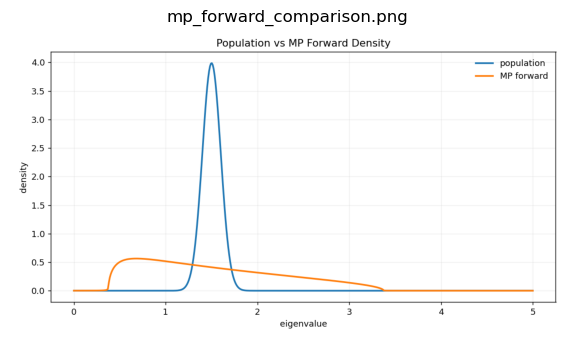

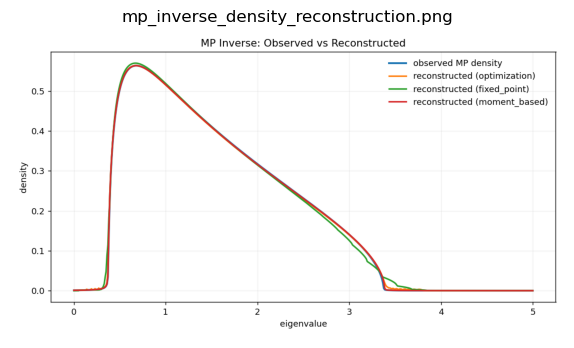

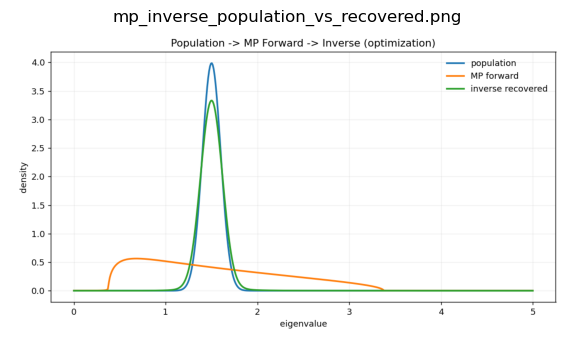

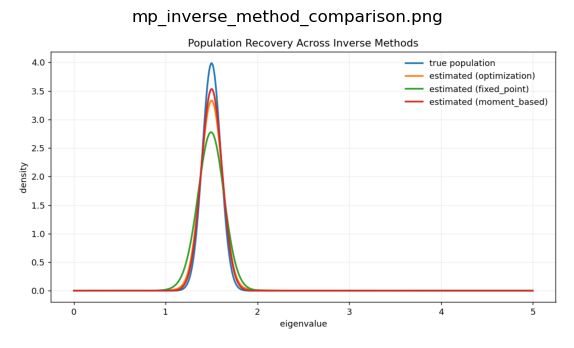

In [4]:
fig_paths = [
    out_dir / 'mp_forward_comparison.png',
    out_dir / 'mp_inverse_density_reconstruction.png',
    out_dir / 'mp_inverse_population_vs_recovered.png',
    out_dir / 'mp_inverse_method_comparison.png',
]

for p in fig_paths:
    if p.exists():
        img = mpimg.imread(p)
        plt.figure(figsize=(10, 4))
        plt.imshow(img)
        plt.title(p.name)
        plt.axis('off')
        plt.show()


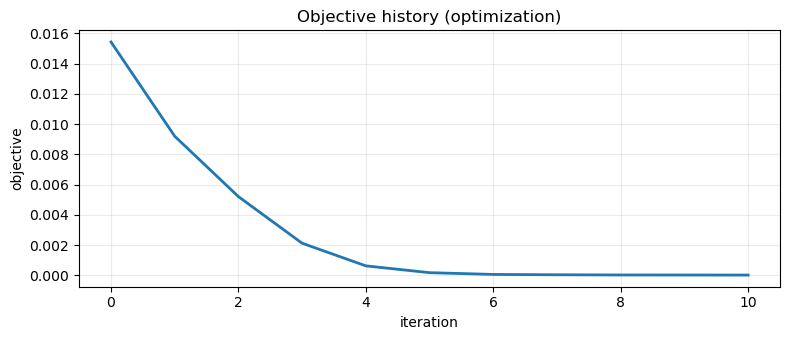

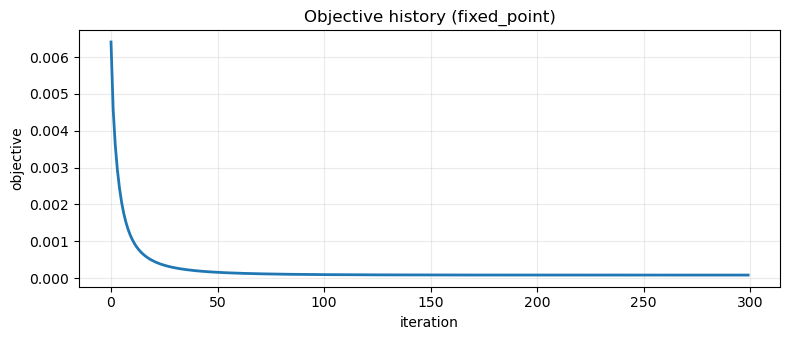

No objective_history available for method: moment_based
{
  "aspect_ratio_c": 0.25,
  "config_path": "/Users/gregoire.szymanski/Documents/random-matrices/configs/spectral_examples/01_dirac_forward_inverse.yaml",
  "method_summaries": {
    "fixed_point": {
      "diagnostics": {
        "converged": false,
        "final_delta": 8.027410636093255e-06,
        "iterations": 300,
        "mean_delta": 0.006973788906779235,
        "objective_history": [
          0.006407594344611437,
          0.004590882406210624,
          0.003607449807625906,
          0.0029330668881022985,
          0.0024335975339884754,
          0.0020512648651267035,
          0.0017528709366512925,
          0.0015164946268148517,
          0.001326739450911153,
          0.0011724813609497375,
          0.0010455596254096804,
          0.0009399245361937509,
          0.0008510510039051476,
          0.0007755245665230726,
          0.0007107453622392575,
          0.0006547147947172074,
          0.00060588

In [5]:
meta_path = out_dir / 'mp_inverse_metadata.json'
if meta_path.exists():
    metadata = json.loads(meta_path.read_text())
    method_summaries = metadata.get('method_summaries', {})

    for method_name in metadata.get('methods', method_summaries.keys()):
        summary = method_summaries.get(method_name, {})
        diagnostics = summary.get('diagnostics', {})
        objective_history = diagnostics.get('objective_history')

        if isinstance(objective_history, list) and objective_history:
            plt.figure(figsize=(8, 3.5))
            plt.plot(objective_history, linewidth=2)
            plt.title(f'Objective history ({method_name})')
            plt.xlabel('iteration')
            plt.ylabel('objective')
            plt.grid(alpha=0.25)
            plt.tight_layout()
            plt.show()
        else:
            print(f'No objective_history available for method: {method_name}')

    print(json.dumps(metadata, indent=2)[:2000])


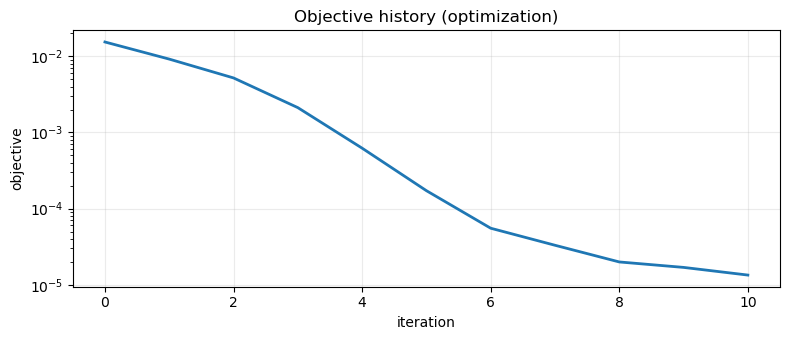

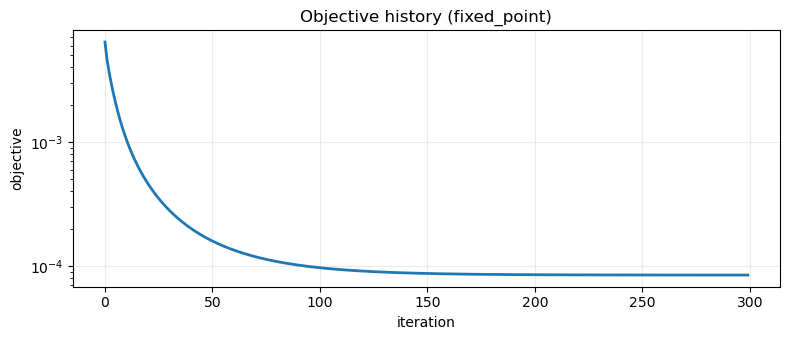

No objective_history available for method: moment_based
{
  "aspect_ratio_c": 0.25,
  "config_path": "/Users/gregoire.szymanski/Documents/random-matrices/configs/spectral_examples/01_dirac_forward_inverse.yaml",
  "method_summaries": {
    "fixed_point": {
      "diagnostics": {
        "converged": false,
        "final_delta": 8.027410636093255e-06,
        "iterations": 300,
        "mean_delta": 0.006973788906779235,
        "objective_history": [
          0.006407594344611437,
          0.004590882406210624,
          0.003607449807625906,
          0.0029330668881022985,
          0.0024335975339884754,
          0.0020512648651267035,
          0.0017528709366512925,
          0.0015164946268148517,
          0.001326739450911153,
          0.0011724813609497375,
          0.0010455596254096804,
          0.0009399245361937509,
          0.0008510510039051476,
          0.0007755245665230726,
          0.0007107453622392575,
          0.0006547147947172074,
          0.00060588

In [6]:
meta_path = out_dir / 'mp_inverse_metadata.json'
if meta_path.exists():
    metadata = json.loads(meta_path.read_text())
    method_summaries = metadata.get('method_summaries', {})

    for method_name in metadata.get('methods', method_summaries.keys()):
        summary = method_summaries.get(method_name, {})
        diagnostics = summary.get('diagnostics', {})
        objective_history = diagnostics.get('objective_history')

        if isinstance(objective_history, list) and objective_history:
            plt.figure(figsize=(8, 3.5))
            plt.plot(objective_history, linewidth=2)
            plt.title(f'Objective history ({method_name})')
            plt.xlabel('iteration')
            plt.ylabel('objective')
            plt.yscale('log')
            plt.grid(alpha=0.25)
            plt.tight_layout()
            plt.show()
        else:
            print(f'No objective_history available for method: {method_name}')

    print(json.dumps(metadata, indent=2)[:2000])
